### PERCEPCION COVID PERSISTENTE con "Redes Neuronales" (3)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Cargar el fichero Excel
file_path = 'percepcion_covid_persistente.xlsx'
df = pd.read_excel(file_path)

# Separar la variable objetivo
X = df.drop(columns=["Consentimiento para participar", "¿Es usted un paciente con síntomas prolongados de COVID-19?"])
y = df["¿Es usted un paciente con síntomas prolongados de COVID-19?"]

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Inicializar el clasificador MLP
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    activation='relu',
                    solver='adam',
                    alpha=0.0001,
                    batch_size='auto',
                    learning_rate='constant',
                    learning_rate_init=0.001,
                    max_iter=200,
                    random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_mlp = mlp.predict(X_test)

# Evaluar el modelo
report_mlp = classification_report(y_test, y_pred_mlp, output_dict=False)
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)

print("Informe de Clasificación:")
print(report_mlp)
print("\nMatriz de Confusión:")
print(conf_matrix_mlp)


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.98      0.99      0.99       107

    accuracy                           0.97       113
   macro avg       0.89      0.83      0.86       113
weighted avg       0.97      0.97      0.97       113


Matriz de Confusión:
[[  4   2]
 [  1 106]]


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.98      0.99      0.99       107

    accuracy                           0.97       113
   macro avg       0.89      0.83      0.86       113
weighted avg       0.97      0.97      0.97       113


Matriz de Confusión:
[[  4   2]
 [  1 106]]

AUC: 0.9548286604361371


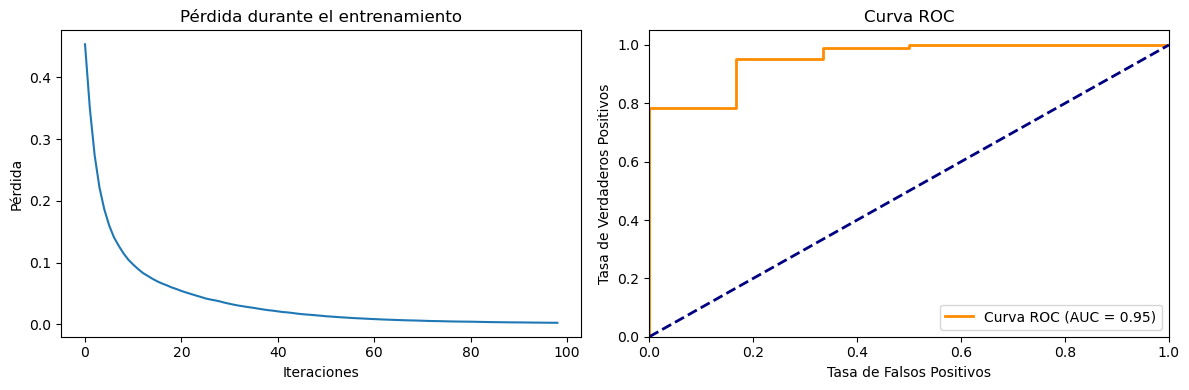

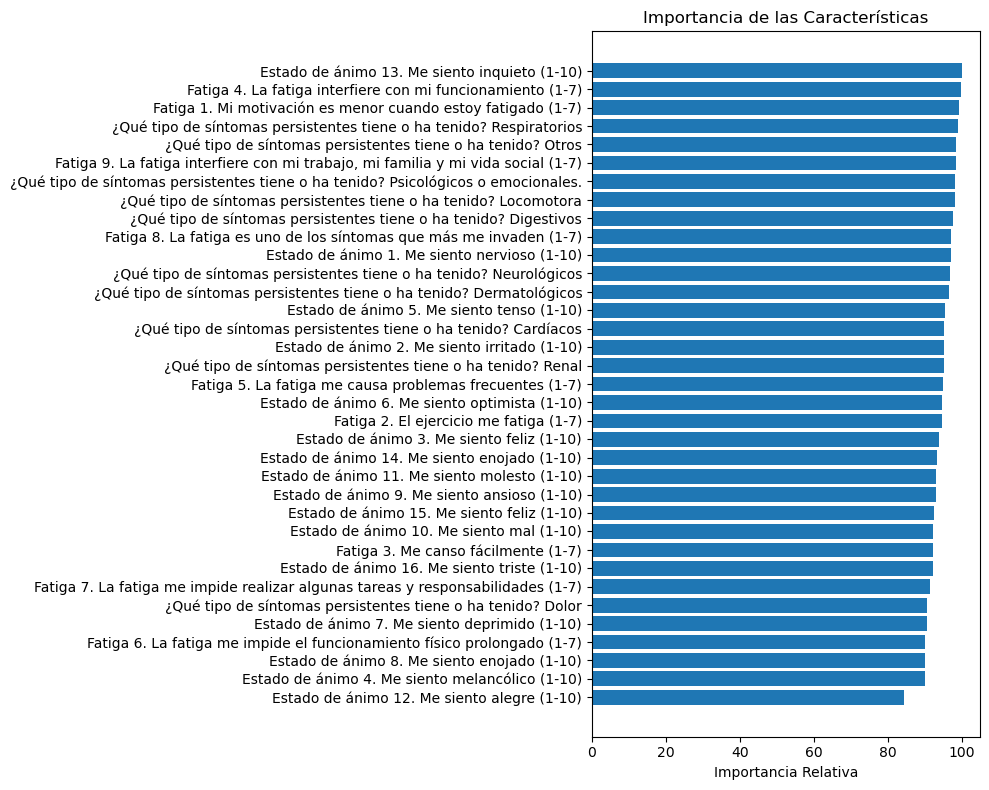

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import joblib

# Cargar el fichero Excel
file_path = 'percepcion_covid_persistente.xlsx'
df = pd.read_excel(file_path)

# Separar la variable objetivo
X = df.drop(columns=["Consentimiento para participar", "¿Es usted un paciente con síntomas prolongados de COVID-19?"])
y = df["¿Es usted un paciente con síntomas prolongados de COVID-19?"]

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Inicializar el clasificador MLP
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    activation='relu',
                    solver='adam',
                    alpha=0.0001,
                    batch_size='auto',
                    learning_rate='constant',
                    learning_rate_init=0.001,
                    max_iter=200,
                    random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred_mlp = mlp.predict(X_test)
y_scores = mlp.predict_proba(X_test)[:, 1]

# 1. Evaluación completa con métricas
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred_mlp))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_mlp))
print("\nAUC:", roc_auc_score(y_test, y_scores))

# 2. Visualizaciones de entrenamiento
# Gráfico de pérdida durante el entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Análisis de importancia de características
feature_importance = np.abs(mlp.coefs_[0]).mean(axis=1)
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.xlabel('Importancia Relativa')
plt.title('Importancia de las Características')
plt.tight_layout()
plt.show()

# 4. Guardar el modelo para uso futuro
joblib.dump(mlp, 'modelo_covid_persistente.joblib')
joblib.dump(scaler, 'scaler_covid_persistente.joblib')

# 5. Función de predicción lista para usar
def predecir_nuevos_datos(nuevos_datos):
    """
    Función para predecir si un paciente tiene síntomas prolongados de COVID-19.
    :param nuevos_datos: DataFrame de pandas con las mismas características que X
    :return: Predicciones (0: No, 1: Sí)
    """
    modelo = joblib.load('modelo_covid_persistente.joblib')
    scaler = joblib.load('scaler_covid_persistente.joblib')
    nuevos_datos_scaled = scaler.transform(nuevos_datos)
    predicciones = modelo.predict(nuevos_datos_scaled)
    return predicciones

# Ejemplo de uso:
# nuevos_datos = pd.DataFrame(...)  # Debe tener las mismas columnas que X
# predicciones = predecir_nuevos_datos(nuevos_datos)


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.98      0.99      0.99       107

    accuracy                           0.97       113
   macro avg       0.89      0.83      0.86       113
weighted avg       0.97      0.97      0.97       113


Matriz de Confusión:
[[  4   2]
 [  1 106]]

AUC: 0.9548286604361371


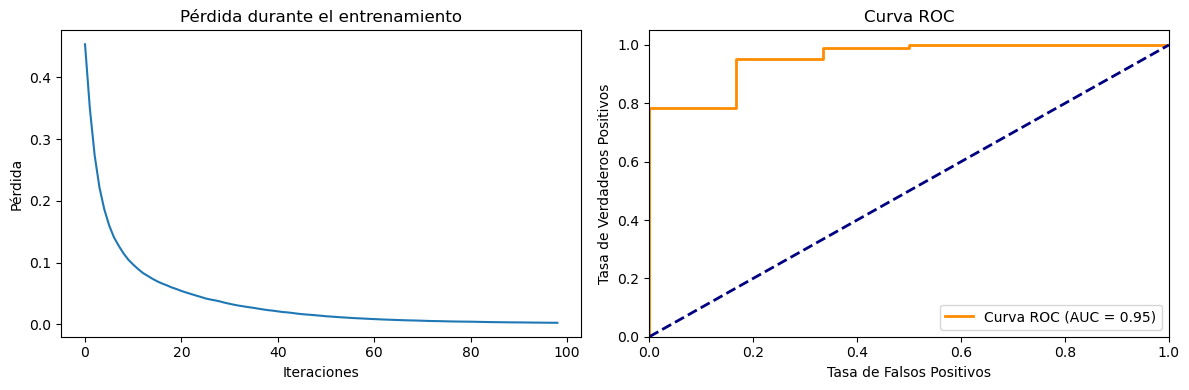

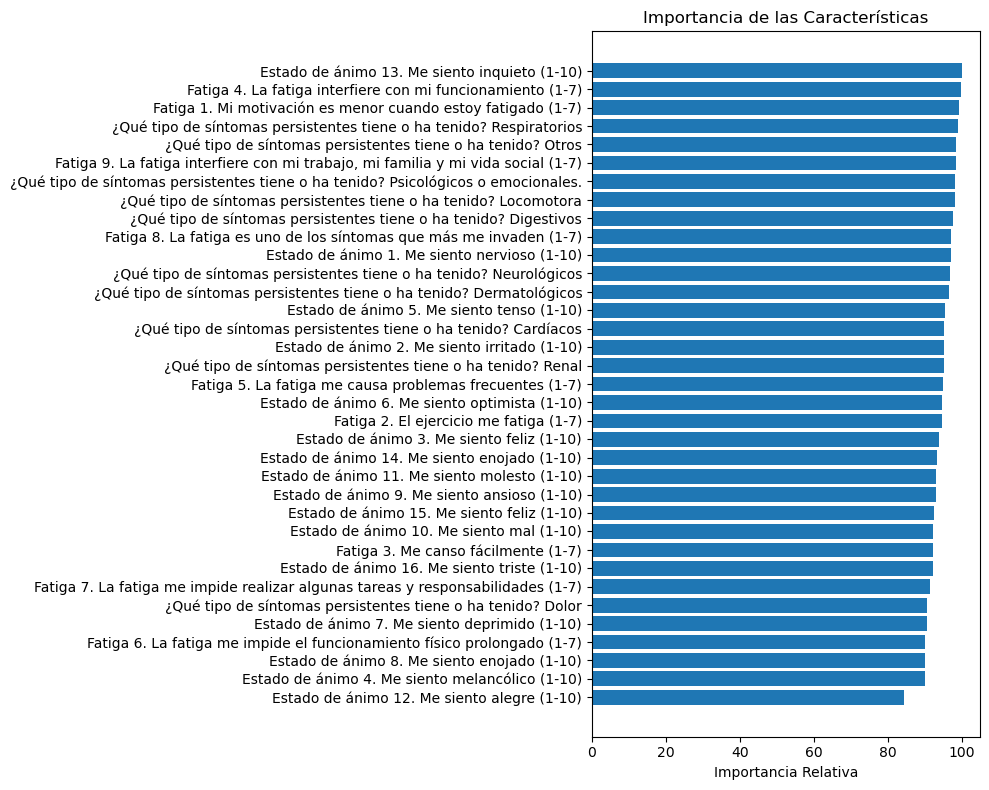

In [3]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import joblib

def entrenar_y_evaluar_modelo(file_path):
    """
    Entrena y evalúa un modelo MLPClassifier para predecir síntomas prolongados de COVID-19.
    :param file_path: Ruta al archivo Excel con los datos
    :return: Modelo entrenado, scaler, y métricas de evaluación
    """
    # Cargar los datos
    df = pd.read_excel(file_path)

    # Separar la variable objetivo
    X = df.drop(columns=["Consentimiento para participar", "¿Es usted un paciente con síntomas prolongados de COVID-19?"])
    y = df["¿Es usted un paciente con síntomas prolongados de COVID-19?"]

    # Normalizar los datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

    # Inicializar y entrenar el modelo MLP
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                        activation='relu',
                        solver='adam',
                        alpha=0.0001,
                        batch_size='auto',
                        learning_rate='constant',
                        learning_rate_init=0.001,
                        max_iter=200,
                        random_state=42)
    mlp.fit(X_train, y_train)

    # Predecir en el conjunto de prueba
    y_pred = mlp.predict(X_test)
    y_scores = mlp.predict_proba(X_test)[:, 1]

    # Evaluar el modelo
    print("Informe de Clasificación:")
    print(classification_report(y_test, y_pred))
    print("\nMatriz de Confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("\nAUC:", roc_auc_score(y_test, y_scores))

    # Visualizar la pérdida durante el entrenamiento
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(mlp.loss_curve_)
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Iteraciones')
    plt.ylabel('Pérdida')

    # Visualizar la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Visualizar la importancia de las características
    feature_importance = np.abs(mlp.coefs_[0]).mean(axis=1)
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
    plt.xlabel('Importancia Relativa')
    plt.title('Importancia de las Características')
    plt.tight_layout()
    plt.show()

    # Guardar el modelo y el scaler
    joblib.dump(mlp, 'modelo_covid_persistente.joblib')
    joblib.dump(scaler, 'scaler_covid_persistente.joblib')

    return mlp, scaler

def predecir_nuevos_datos(nuevos_datos):
    """
    Predice si un paciente tiene síntomas prolongados de COVID-19.
    :param nuevos_datos: DataFrame de pandas con las mismas características que X
    :return: Predicciones (0: No, 1: Sí)
    """
    modelo = joblib.load('modelo_covid_persistente.joblib')
    scaler = joblib.load('scaler_covid_persistente.joblib')
    nuevos_datos_scaled = scaler.transform(nuevos_datos)
    predicciones = modelo.predict(nuevos_datos_scaled)
    return predicciones

# Ejemplo de uso
if __name__ == "__main__":
    # Entrenar y evaluar el modelo
    modelo, scaler = entrenar_y_evaluar_modelo('percepcion_covid_persistente.xlsx')

    # Ejemplo de predicción (descomentar y ajustar según tus datos)
    # nuevos_datos = pd.DataFrame(...)  # Debe tener las mismas columnas que X
    # predicciones = predecir_nuevos_datos(nuevos_datos)
    # print("Predicciones:", predicciones)
